### `Librairies`

In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, precision_score
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np


### `Données`

In [ ]:
# Importer les données 
cancer = pd.read_csv("process/cancer_clean.csv")


In [3]:
cancer.shape

(557, 11)

In [4]:
cancer.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,symmetry_mean,fractal_dimension_mean,concave_points_mean
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.2419,0.07871,0.14710
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.1812,0.05667,0.07017
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.2069,0.05999,0.12790
3,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.1809,0.05883,0.10430
4,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.2087,0.07613,0.08089


### `Split data`

In [5]:
# X et y 
X = cancer.drop("diagnosis", axis=1)
y = cancer["diagnosis"]

# X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=3)


---

### `Calculer la variance pour chaque feature`

In [51]:
# Minmaxscaler 
MinMax_scaler = MinMaxScaler()

# Mise à l'éechelle des variables 
X_scaler = MinMax_scaler.fit_transform(X)


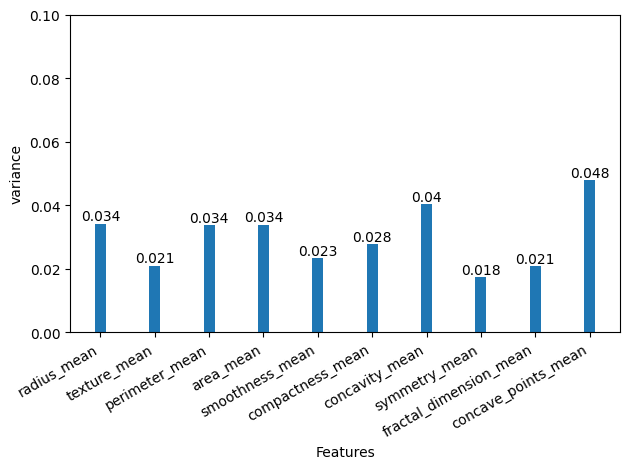

In [7]:
fig, ax = plt.subplots()

x = X.columns
y = X_scaler.var(axis=0) 

ax.bar(x, y, width=0.2)
ax.set_xlabel("Features")
ax.set_ylabel("variance")
ax.set_ylim(0, 0.1)

for index, value in enumerate(y): 
    plt.text(x=index, y=value+0.001, 
            s=str(round(value, 3)), ha="center")

fig.autofmt_xdate()
plt.tight_layout()

---

### `Standardisation` 

In [53]:
# Minmaxscaler 
MinMax_scaler = MinMaxScaler()

# Mise à l'échelle des variables 
X_train_scaler1 = MinMax_scaler.fit_transform(X_train)
X_test_scaler1= MinMax_scaler.transform(X_test)

# as dataframe
X_train_scaler1 = pd.DataFrame(X_train_scaler1,columns=X.columns) 
X_test_scaler1 = pd.DataFrame(X_test_scaler1,columns=X.columns) 

# Supprimer la variable "fractal_dimension_mean"
X_train_scaler = X_train_scaler1.drop(["fractal_dimension_mean"], axis=1)
X_test_scaler = X_test_scaler1.drop(["fractal_dimension_mean"], axis=1)

In [54]:

# Sélection de variable 
X_train_v1 = X_train_scaler1.drop(["radius_mean", "area_mean",  "concavity_mean", "compactness_mean"], axis = 1)
X_test_v1 = X_test_scaler1.drop(["radius_mean", "area_mean", "concavity_mean", "compactness_mean"], axis = 1)



### `Entrainement des algorithmes de classification`

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, validation_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report


--- 

### `Régression logistique`

In [59]:
# Avec toutes les variables 
logistic = LogisticRegression(random_state=179)
reg_log = logistic.fit(X_train_scaler, y_train)
accuracy_all = accuracy_score(y_test, logistic.predict(X_test_scaler))
accuracy_all

print(classification_report(y_test, reg_log.predict(X_test_scaler)))


              precision    recall  f1-score   support

           B       0.90      0.98      0.94       111
           M       0.96      0.79      0.87        57

    accuracy                           0.92       168
   macro avg       0.93      0.89      0.90       168
weighted avg       0.92      0.92      0.91       168



In [60]:
# Avec sélection de variabkes 
logistic = LogisticRegression(random_state=179)
reg_log = logistic.fit(X_train_v1, y_train)
accuracy_variance = accuracy_score(y_test, reg_log.predict(X_test_v1))
accuracy_variance


print(classification_report(y_test, reg_log.predict(X_test_v1)))


              precision    recall  f1-score   support

           B       0.90      1.00      0.95       111
           M       1.00      0.79      0.88        57

    accuracy                           0.93       168
   macro avg       0.95      0.89      0.92       168
weighted avg       0.94      0.93      0.93       168



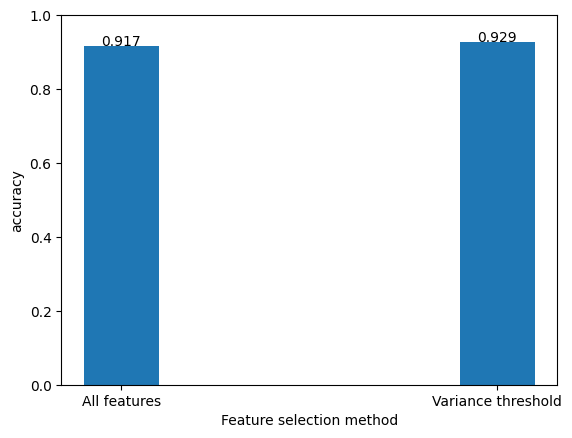

In [61]:
# All features VS Variance selection 
fig, ax = plt.subplots()

x = ["All features", "Variance threshold"]
y = [accuracy_all, accuracy_variance]

ax.bar(x, y, width=0.2)
ax.set_xlabel("Feature selection method")
ax.set_ylabel("accuracy")
ax.set_ylim(0, 1)

for index, value in enumerate(y) : 
    plt.text(x = index, y = value, s = str(round(value, 3)), ha="center")

plt.show()


---

### `DecisionTreeClassifier`

In [62]:
# Avec toutes les variables 
tree = DecisionTreeClassifier(random_state=179)
tree = tree.fit(X_train_scaler, y_train)
accuracy_all = accuracy_score(y_test, tree.predict(X_test_scaler))
accuracy_all

print(classification_report(y_test, tree.predict(X_test_scaler)))


              precision    recall  f1-score   support

           B       0.93      0.94      0.93       111
           M       0.88      0.86      0.87        57

    accuracy                           0.91       168
   macro avg       0.90      0.90      0.90       168
weighted avg       0.91      0.91      0.91       168



In [63]:
# Avec sélection de variabkes 
tree = DecisionTreeClassifier(random_state=179)
tree = tree.fit(X_train_v1, y_train)
accuracy_variance = accuracy_score(y_test, tree.predict(X_test_v1))
accuracy_variance

print(classification_report(y_test, tree.predict(X_test_v1)))


              precision    recall  f1-score   support

           B       0.94      0.91      0.92       111
           M       0.83      0.88      0.85        57

    accuracy                           0.90       168
   macro avg       0.88      0.89      0.89       168
weighted avg       0.90      0.90      0.90       168



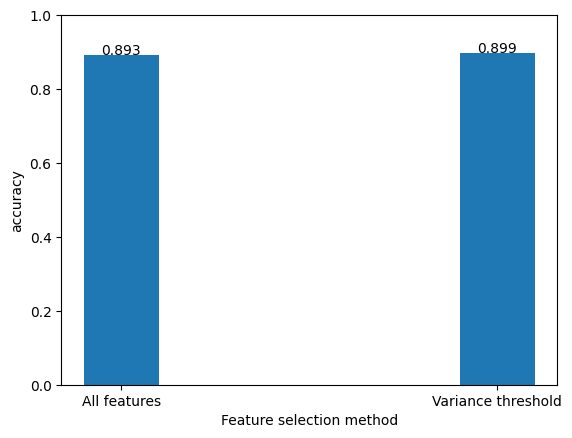

In [16]:

fig, ax = plt.subplots()

x = ["All features", "Variance threshold"]
y = [accuracy_all, accuracy_variance]

ax.bar(x, y, width=0.2)
ax.set_xlabel("Feature selection method")
ax.set_ylabel("accuracy")
ax.set_ylim(0, 1)

for index, value in enumerate(y) : 
    plt.text(x = index, y = value, s = str(round(value, 3)), ha="center")

plt.show()


---

### `RandomForestClassifier`

In [64]:
# Avec toutes les variables 
forest = RandomForestClassifier(random_state=179)
forest = forest.fit(X_train_scaler, y_train)
accuracy_all = accuracy_score(y_test, forest.predict(X_test_scaler))
accuracy_all

print(classification_report(y_test, forest.predict(X_test_scaler)))


              precision    recall  f1-score   support

           B       0.93      0.95      0.94       111
           M       0.89      0.86      0.88        57

    accuracy                           0.92       168
   macro avg       0.91      0.90      0.91       168
weighted avg       0.92      0.92      0.92       168



In [65]:
# Avec sélection de variables 
forest = RandomForestClassifier(random_state=179)
forest = forest.fit(X_train_v1, y_train)
accuracy_variance = accuracy_score(y_test, forest.predict(X_test_v1))
accuracy_variance

print(classification_report(y_test, forest.predict(X_test_v1)))


              precision    recall  f1-score   support

           B       0.94      0.95      0.94       111
           M       0.89      0.88      0.88        57

    accuracy                           0.92       168
   macro avg       0.92      0.91      0.91       168
weighted avg       0.92      0.92      0.92       168



In [ ]:
from sklearn.metrics import recall_score, precision_score

recall_score(y_test, forest.predict(X_test_v1), average="macro")

0.9115694642010431

In [45]:
precision_score(y_test, forest.predict(X_test_v1), average="macro")

0.9151785714285714

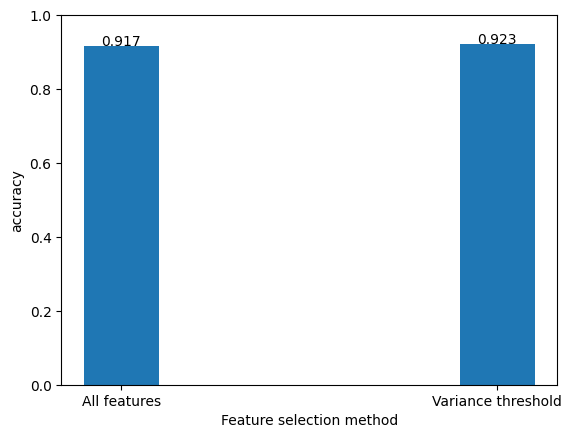

In [21]:
fig, ax = plt.subplots()

x = ["All features", "Variance threshold"]
y = [accuracy_all, accuracy_variance]

ax.bar(x, y, width=0.2)
ax.set_xlabel("Feature selection method")
ax.set_ylabel("accuracy")
ax.set_ylim(0, 1)

for index, value in enumerate(y) : 
    plt.text(x = index, y = value, s = str(round(value, 3)), ha="center")

plt.show()



---

### `ExtraTreesClassifier`

In [66]:
# Avec toutes les données 
extra_tree = ExtraTreesClassifier(random_state=179)
extra_tree = extra_tree.fit(X_train_scaler, y_train)
accuracy_all = accuracy_score(y_test, extra_tree.predict(X_test_scaler))
accuracy_all

print(classification_report(y_test, extra_tree.predict(X_test_scaler)))


              precision    recall  f1-score   support

           B       0.93      0.95      0.94       111
           M       0.89      0.86      0.88        57

    accuracy                           0.92       168
   macro avg       0.91      0.90      0.91       168
weighted avg       0.92      0.92      0.92       168



In [67]:
# Avec sélection des données 
extra_tree = ExtraTreesClassifier(random_state=179)
extra_tree = extra_tree.fit(X_train_v1, y_train)
accuracy_variance = accuracy_score(y_test, extra_tree.predict(X_test_v1))
accuracy_variance

print(classification_report(y_test, extra_tree.predict(X_test_v1)))


              precision    recall  f1-score   support

           B       0.94      0.96      0.95       111
           M       0.93      0.88      0.90        57

    accuracy                           0.93       168
   macro avg       0.93      0.92      0.93       168
weighted avg       0.93      0.93      0.93       168



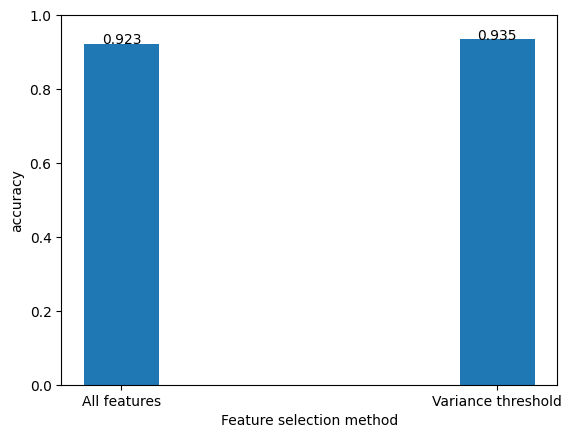

In [24]:
fig, ax = plt.subplots()

x = ["All features", "Variance threshold"]
y = [accuracy_all, accuracy_variance]

ax.bar(x, y, width=0.2)
ax.set_xlabel("Feature selection method")
ax.set_ylabel("accuracy")
ax.set_ylim(0, 1)

for index, value in enumerate(y) : 
    plt.text(x = index, y = value, s = str(round(value, 3)), ha="center")

plt.show()


---

### `GradientBoostingClassifier`

In [25]:
# Avec toutes les données 
booster = GradientBoostingClassifier(random_state=179)
booster = booster.fit(X_train_scaler, y_train)
accuracy_all = accuracy_score(y_test, booster.predict(X_test_scaler))
accuracy_all

print(classification_report(y_test, booster.predict(X_test_scaler)))


              precision    recall  f1-score   support

           B       0.95      0.95      0.95       111
           M       0.89      0.89      0.89        57

    accuracy                           0.93       168
   macro avg       0.92      0.92      0.92       168
weighted avg       0.93      0.93      0.93       168



In [26]:
# Avec sélection des données 
booster2 = GradientBoostingClassifier(random_state=179)
booster2 = booster2.fit(X_train_v1, y_train)
accuracy_variance = accuracy_score(y_test, booster2.predict(X_test_v1))
accuracy_variance

print(classification_report(y_test, booster2.predict(X_test_v1)))


              precision    recall  f1-score   support

           B       0.94      0.95      0.95       111
           M       0.91      0.88      0.89        57

    accuracy                           0.93       168
   macro avg       0.92      0.92      0.92       168
weighted avg       0.93      0.93      0.93       168



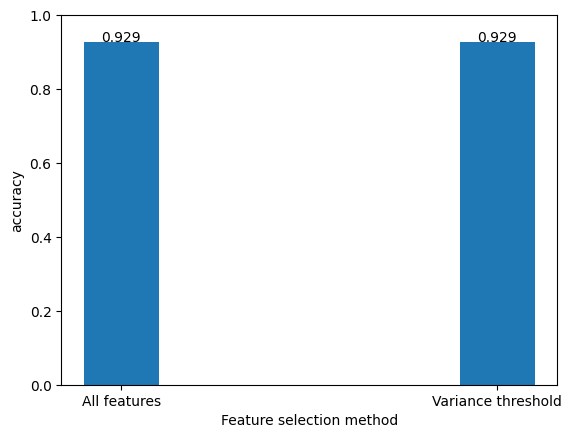

In [27]:

fig, ax = plt.subplots()

x = ["All features", "Variance threshold"]
y = [accuracy_all, accuracy_variance]

ax.bar(x, y, width=0.2)
ax.set_xlabel("Feature selection method")
ax.set_ylabel("accuracy")
ax.set_ylim(0, 1)

for index, value in enumerate(y) : 
    plt.text(x = index, y = value, s = str(round(value, 3)), ha="center")

plt.show()


---

### `AdaBoostClassifier`

In [28]:
from sklearn.ensemble import AdaBoostClassifier, HistGradientBoostingClassifier

In [29]:
# Avec toutes les données 
ada = AdaBoostClassifier(random_state=179)
ada = ada.fit(X_train_scaler, y_train)
accuracy_all = accuracy_score(y_test, ada.predict(X_test_scaler))
accuracy_all

print(classification_report(y_test, ada.predict(X_test_scaler)))


              precision    recall  f1-score   support

           B       0.95      0.95      0.95       111
           M       0.90      0.91      0.90        57

    accuracy                           0.93       168
   macro avg       0.93      0.93      0.93       168
weighted avg       0.93      0.93      0.93       168



In [30]:
# Avec sélection des données 
ada = AdaBoostClassifier(random_state=179)
ada = ada.fit(X_train_v1, y_train)
accuracy_variance = accuracy_score(y_test, ada.predict(X_test_v1))
accuracy_variance

print(classification_report(y_test, ada.predict(X_test_v1)))


              precision    recall  f1-score   support

           B       0.95      0.94      0.95       111
           M       0.88      0.91      0.90        57

    accuracy                           0.93       168
   macro avg       0.92      0.92      0.92       168
weighted avg       0.93      0.93      0.93       168



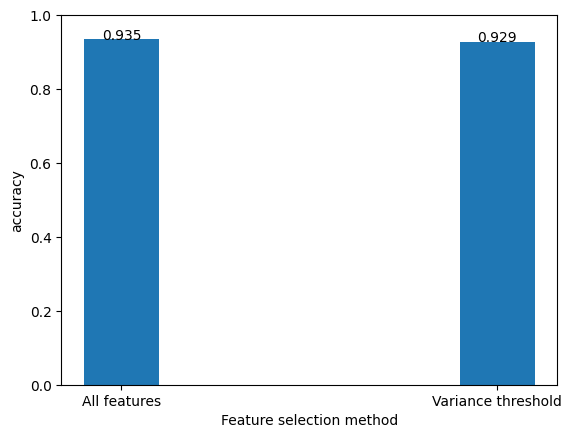

In [31]:

fig, ax = plt.subplots()

x = ["All features", "Variance threshold"]
y = [accuracy_all, accuracy_variance]

ax.bar(x, y, width=0.2)
ax.set_xlabel("Feature selection method")
ax.set_ylabel("accuracy")
ax.set_ylim(0, 1)

for index, value in enumerate(y) : 
    plt.text(x = index, y = value, s = str(round(value, 3)), ha="center")

plt.show()


---

### `HHistGradientBoostingClassifier`

In [32]:
hsitgrad = HistGradientBoostingClassifier(random_state=179)
hsitgrad = hsitgrad.fit(X_train_scaler, y_train)
accuracy_all = accuracy_score(y_test, hsitgrad.predict(X_test_scaler))
accuracy_all

print(classification_report(y_test, hsitgrad.predict(X_test_scaler)))


              precision    recall  f1-score   support

           B       0.95      0.95      0.95       111
           M       0.91      0.89      0.90        57

    accuracy                           0.93       168
   macro avg       0.93      0.92      0.93       168
weighted avg       0.93      0.93      0.93       168



In [33]:
# Avec sélection des données 
hsitgrad = HistGradientBoostingClassifier(random_state=179)
hsitgrad = hsitgrad.fit(X_train_v1, y_train)
accuracy_variance = accuracy_score(y_test, hsitgrad.predict(X_test_v1))
accuracy_variance

print(classification_report(y_test, hsitgrad.predict(X_test_v1)))


              precision    recall  f1-score   support

           B       0.94      0.95      0.95       111
           M       0.91      0.88      0.89        57

    accuracy                           0.93       168
   macro avg       0.92      0.92      0.92       168
weighted avg       0.93      0.93      0.93       168



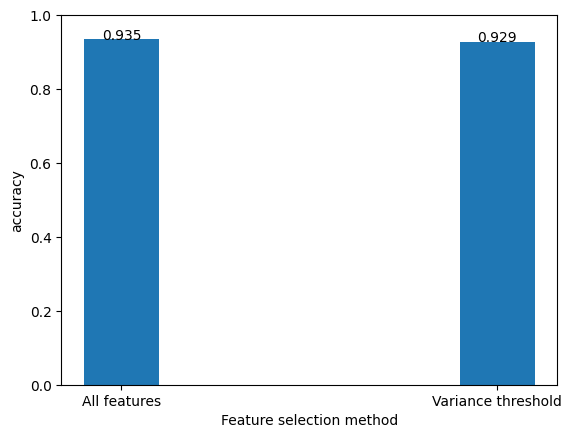

In [34]:

fig, ax = plt.subplots()

x = ["All features", "Variance threshold"]
y = [accuracy_all, accuracy_variance]

ax.bar(x, y, width=0.2)
ax.set_xlabel("Feature selection method")
ax.set_ylabel("accuracy")
ax.set_ylim(0, 1)

for index, value in enumerate(y) : 
    plt.text(x = index, y = value, s = str(round(value, 3)), ha="center")

plt.show()


---

### `Sélection de modèles`

À l’issue de la phase d’entraînement initiale, les modèles retenus pour l’étape d’optimisation des hyperparamètres sont les suivants :

- Random Forest
- Gradient Boosting Classifier
- AdaBoost Classifier

Justification méthodologique

L’objectif principal de cette étude est la minimisation des faux négatifs, ce qui implique de privilégier des modèles présentant un rappel (recall) supérieur à 90 %, critère critique dans un contexte de diagnostic médical. Les modèles sélectionnés offrent un compromis satisfaisant entre rappel, spécificité et précision, garantissant à la fois une bonne capacité de détection des cas malins et une limitation des faux positifs.

Les modèles ont été entraînés dans un premier temps sans optimisation des hyperparamètres, en utilisant exclusivement leurs paramètres par défaut, afin d’établir une ligne de base (baseline) de performance.

Une étape de sélection de caractéristiques (feature selection) a été mise en œuvre. Elle repose d’abord sur une analyse de la variance, permettant d’éliminer les variables faiblement informatives. Ensuite, une réduction de la multicolinéarité a été effectuée en supprimant les variables présentant un coefficient de corrélation supérieur à 97 %, afin de limiter la redondance informationnelle et d’améliorer la stabilité des modèles.

Les modèles finalement retenus sont ceux ayant obtenu les meilleures performances sur l’espace de caractéristiques réduit, tant en termes de métriques de classification que de robustesse générale.


---

In [35]:
# Enreistrer le modèle gradienbosstingclassifiier 

import pickle


pickle.dump(booster, open("model_gradientBoost.pkl", "wb"))
pickle.dump(MinMax_scaler, open("MinMax_scaler.pkl", "wb"))


### `Optimisation des hyperparametres`

A Suivre ...